In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

!git clone https://github.com/Break-Through-Tech/WWEX-1A-delivery-performance-and-smart-carrier-selection-for-multi-carrier-shipping.git

train = pd.read_csv('WWEX-1A-delivery-performance-and-smart-carrier-selection-for-multi-carrier-shipping/data/train.csv')
test = pd.read_csv('WWEX-1A-delivery-performance-and-smart-carrier-selection-for-multi-carrier-shipping/data/test.csv')

Cloning into 'WWEX-1A-delivery-performance-and-smart-carrier-selection-for-multi-carrier-shipping'...
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 66 (delta 33), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (66/66), 2.72 MiB | 3.81 MiB/s, done.
Resolving deltas: 100% (33/33), done.


In [ ]:
# Load the raw data. ZIPs are read as text so we don't lose leading zeros
path = "WWEX-1A-delivery-performance-and-smart-carrier-selection-for-multi-carrier-shipping/data/"
train = pd.read_csv(path + "train.csv", dtype={"origin_zip": str, "dest_zip": str})
test = pd.read_csv(path + "test.csv", dtype={"origin_zip": str, "dest_zip": str})

# The correct spellings we want to end up with
carriers = ["Falcon Post", "Northstar Parcel", "Summit Express",
            "Ironclad Freight", "Vela Freight", "Cobalt Regional"]
services = ["Ground", "Expedited", "TwoDay", "Overnight", "LTL Standard", "LTL Guaranteed"]

# Lookup: lowercase version -> correct spelling (e.g. "falcon post" -> "Falcon Post")
carrier_map = {n.lower(): n for n in carriers}
service_map = {n.lower(): n for n in services}

# Columns that have missing or messy numbers
fill_cols = ["weight_lbs", "length_in", "width_in", "height_in"]

# Steps 1-3 run on both train and test
for df in (train, test):
    # 1. Fix messy text: remove extra spaces, make lowercase, then swap in the correct spelling
    df["carrier"] = df["carrier"].str.strip().str.lower().map(carrier_map)
    df["service_level"] = df["service_level"].str.strip().str.lower().map(service_map)

    # 2. Fix ZIPs: put back the leading zero that got lost (2108 -> 02108)
    for c in ["origin_zip", "dest_zip"]:
        df[c] = df[c].str.strip().str.zfill(5)

    # 3. Turn date text into real dates so we can sort by time later
    df["order_date"] = pd.to_datetime(df["order_date"])
    df["ship_date"] = pd.to_datetime(df["ship_date"])

# 4. Remove duplicate rows (done after the text cleanup so near-duplicates get caught too)
train = train.drop_duplicates().reset_index(drop=True)
test = test.drop_duplicates().reset_index(drop=True)

for df in (train, test):
    # 5a. A weight of 0 isn't real, so treat it as missing
    df.loc[df["weight_lbs"] == 0, "weight_lbs"] = np.nan

    # 5b. Find weights that are way too big (these were grams typed in as pounds)
    grams = ((df["shipment_mode"] == "parcel") & (df["weight_lbs"] > 150)) | \
            ((df["shipment_mode"] == "ltl_freight") & (df["weight_lbs"] > 20000))

    # 5c. Convert those from grams to pounds
    df.loc[grams, "weight_lbs"] = df.loc[grams, "weight_lbs"] / 453.592

    # 6. Mark which values were missing BEFORE we fill them in
    for c in fill_cols:
        df[c + "_na"] = df[c].isnull()

# 7. Fill missing values with the typical (median) value for that shipment type
# Medians come from train only, so test doesn't leak into our results
meds = train.groupby("shipment_mode")[fill_cols].median()
print(meds)
for df in (train, test):
    for c in fill_cols:
        df[c] = df[c].fillna(df["shipment_mode"].map(meds[c]))

# Checks: make sure everything worked
print(len(train), len(test))                        # expect about 39,949 and 10,114
print(train[fill_cols].isnull().sum().sum(), test[fill_cols].isnull().sum().sum())   # expect 0 0
print(train.groupby("shipment_mode")[fill_cols].describe().T)   # weights should look realistic now

# Date ranges (we need these to decide how to split the data)
print("train:", train["ship_date"].min().date(), "to", train["ship_date"].max().date())
print("test: ", test["ship_date"].min().date(), "to", test["ship_date"].max().date())

               weight_lbs  length_in  width_in  height_in
shipment_mode                                            
ltl_freight       494.475       42.0      35.1       27.8
parcel              3.340        7.9       6.6        5.3
39949 10114
0 0
shipment_mode     ltl_freight        parcel
weight_lbs count  5907.000000  34042.000000
           mean    590.947741      4.365070
           std     403.645157      3.737966
           min     150.000000      0.200000
           25%     335.480000      2.050000
           50%     494.475000      3.340000
           75%     724.675000      5.390000
           max    6975.340000     70.000000
length_in  count  5907.000000  34042.000000
           mean     43.320637      8.271967
           std      12.049205      2.625833
           min      19.100000      4.000000
           25%      34.400000      6.400000
           50%      42.000000      7.900000
           75%      50.400000      9.800000
           max     108.000000     29.500000
widt

In [ ]:
train.head()

,shipment_id,order_date,ship_date,ship_dow,ship_month,shipment_mode,carrier,service_level,origin_metro,dest_metro,...,weather_severity,carrier_congestion_index,promised_days,carrier_cost_usd,transit_days,delivered_on_time,weight_lbs_na,length_in_na,width_in_na,height_in_na
0,SHP-42-0003885,2024-04-23,2024-04-23,1,4,parcel,Cobalt Regional,Overnight,Los Angeles CA,Salt Lake City UT,...,0.108,0.000,2,29.53,1,1,False,False,False,False
1,SHP-42-0010239,2025-01-07,2025-01-09,3,1,parcel,Northstar Parcel,Expedited,Seattle WA,New York NY,...,0.273,0.206,4,28.30,3,1,False,False,False,False
2,SHP-42-0035486,2025-07-30,2025-07-30,2,7,ltl_freight,Vela Freight,LTL Standard,Atlanta GA,Miami FL,...,0.222,0.119,9,205.09,8,1,False,False,False,False
3,SHP-42-0008180,2025-03-24,2025-03-26,2,3,parcel,Northstar Parcel,Ground,New York NY,Salt Lake City UT,...,0.046,0.287,7,11.79,6,1,False,False,False,False
4,SHP-42-0015190,2025-05-06,2025-05-08,3,5,parcel,Falcon Post,Expedited,Los Angeles CA,Columbus OH,...,0.273,0.120,4,13.13,6,0,False,False,False,False


In [ ]:
test.head()

,shipment_id,order_date,ship_date,ship_dow,ship_month,shipment_mode,carrier,service_level,origin_metro,dest_metro,...,declared_value_usd,fuel_surcharge_pct,weather_severity,carrier_congestion_index,promised_days,carrier_cost_usd,weight_lbs_na,length_in_na,width_in_na,height_in_na
0,SHP-42-0039072,2024-12-04,2024-12-08,6,12,parcel,Falcon Post,Ground,Houston TX,Chicago IL,...,40.17,0.1843,0.554,0.825,6,11.30,False,False,False,False
1,SHP-42-0034359,2025-01-08,2025-01-08,2,1,parcel,Northstar Parcel,Ground,Chicago IL,Atlanta GA,...,83.47,0.1555,0.514,0.164,5,11.29,False,False,False,False
2,SHP-42-0046338,2024-11-22,2024-11-26,1,11,parcel,Falcon Post,Ground,Miami FL,Atlanta GA,...,43.81,0.0830,0.106,0.756,6,10.15,False,False,False,False
3,SHP-42-0023605,2024-02-29,2024-03-01,4,3,parcel,Falcon Post,Ground,Dallas TX,Miami FL,...,0.00,0.0997,0.198,0.159,6,19.26,False,False,False,False
4,SHP-42-0015811,2024-07-13,2024-07-15,0,7,parcel,Northstar Parcel,Expedited,Phoenix AZ,Boston MA,...,259.72,0.0866,0.019,0.160,4,21.43,False,False,False,False


Text(0, 0.5, 'Frequency')

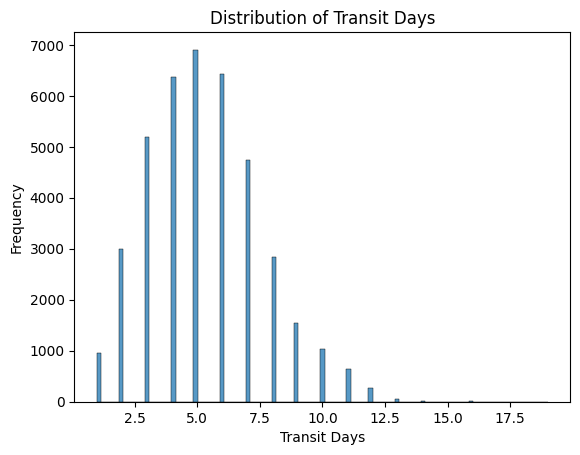

In [ ]:
# Histogram of Transit Days distribution
sns.histplot(data=train, x = "transit_days" )
plt.title("Distribution of Transit Days")
plt.xlabel("Transit Days")
plt.ylabel("Frequency")

([<matplotlib.axis.XTick at 0x7eb614997e00>,
 [Text(0, 0, 'Late'), Text(1, 0, 'On-time')])

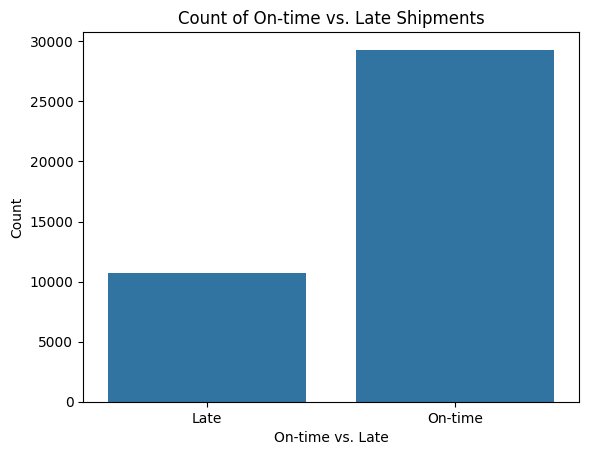

In [ ]:
# Plot of counts for on-time vs. late shipments
sns.countplot(data=train, x = "delivered_on_time" )
plt.title("Count of On-time vs. Late Shipments")
plt.xlabel("On-time vs. Late")
plt.ylabel("Count")

plt.xticks(ticks=[0, 1], labels=["Late", "On-time"])

Text(0, 0.5, 'Transit Days')

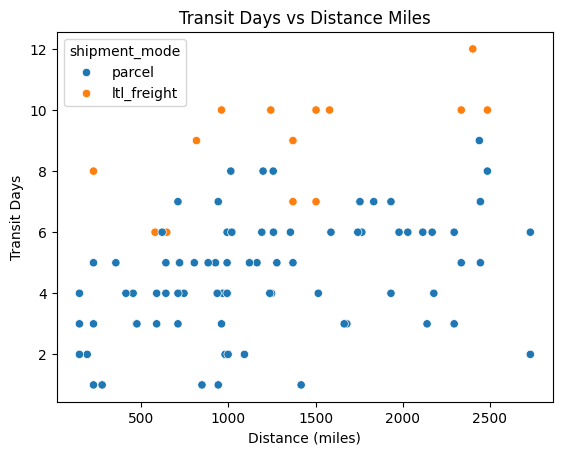

In [ ]:
# Scatterplot for Transit Days vs. Distance Miles by Shipment Mode
sns.scatterplot(data=train.sample(100), x = "distance_miles", y = "transit_days", hue = "shipment_mode")

plt.title("Transit Days vs Distance Miles")
plt.xlabel("Distance (miles)")
plt.ylabel("Transit Days")

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Ground'),
  Text(1, 0, 'Expedited'),
  Text(2, 0, 'TwoDay'),
  Text(3, 0, 'Overnight'),
  Text(4, 0, 'LTL Standard'),
  Text(5, 0, 'LTL Guaranteed')])

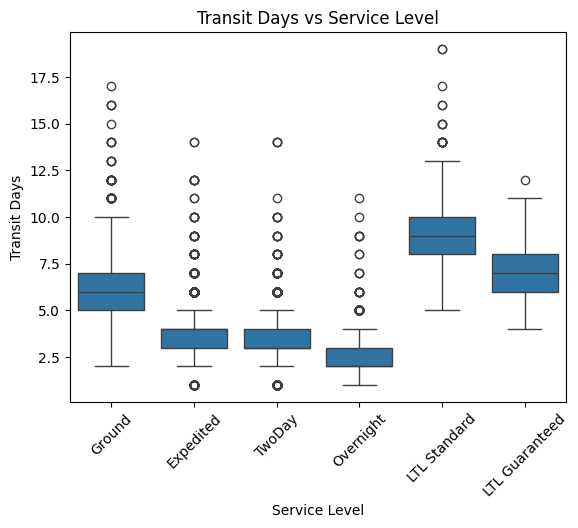

In [ ]:
# Boxplot of Transit Days vs. Service Level
level = ['Ground', 'Expedited', 'TwoDay', 'Overnight', 'LTL Standard', 'LTL Guaranteed']
sns.boxplot(data = train, x = 'service_level', y = 'transit_days', order = level)
plt.title("Transit Days vs Service Level")
plt.xlabel("Service Level")
plt.ylabel("Transit Days")
plt.xticks(rotation=45)

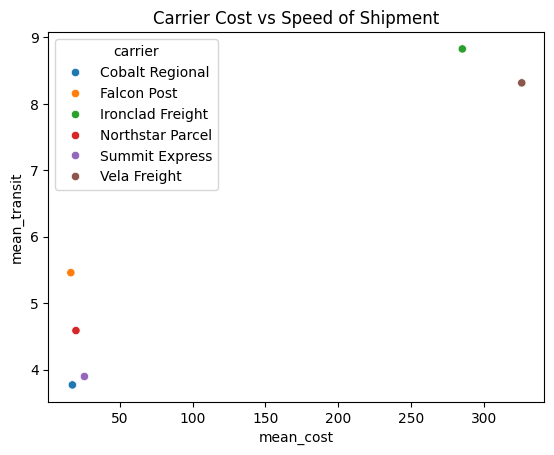

In [ ]:
# Scatterplot of Carrier Cost vs. Speed of Shipment
carrier_data = train.groupby('carrier').agg(
    mean_transit=('transit_days','mean'),
    on_time_rate=('delivered_on_time','mean'),
    mean_cost=('carrier_cost_usd','mean')
)

sns.scatterplot(data=carrier_data, x='mean_cost', y='mean_transit', hue='carrier')
plt.title("Carrier Cost vs Speed of Shipment")
plt.show()

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]),
 [Text(0, 0, 'January'),
  Text(1, 0, 'February'),
  Text(2, 0, 'March'),
  Text(3, 0, 'April'),
  Text(4, 0, 'May'),
  Text(5, 0, 'June'),
  Text(6, 0, 'July'),
  Text(7, 0, 'August'),
  Text(8, 0, 'September'),
  Text(9, 0, 'October'),
  Text(10, 0, 'November'),
  Text(11, 0, 'December')])

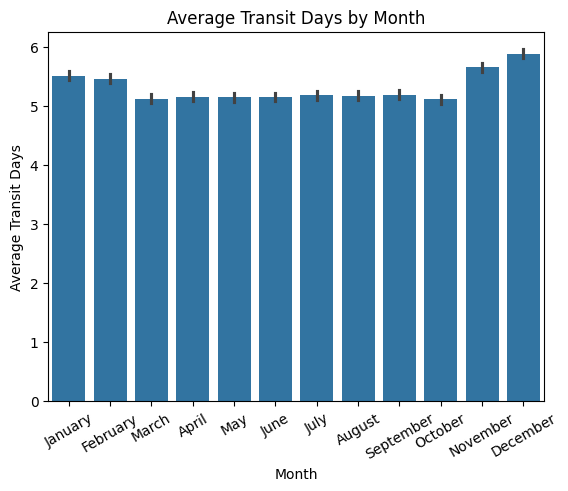

In [ ]:
# Barplot of Average Transit Days by Month
sns.barplot(data=train, x='ship_month', y='transit_days', estimator='mean')
plt.title('Average Transit Days by Month')
plt.xlabel("Month")
plt.ylabel("Average Transit Days")

months = ["January", "February", "March", "April", "May", "June", "July", "August",
"September", "October", "November", "December"]
plt.xticks(
    ticks=range(12),
    labels=months
)
plt.xticks(rotation=30)

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Monday'),
  Text(1, 0, 'Tuesday'),
  Text(2, 0, 'Wednesday'),
  Text(3, 0, 'Thursday'),
  Text(4, 0, 'Friday'),
  Text(5, 0, 'Saturday'),
  Text(6, 0, 'Sunday')])

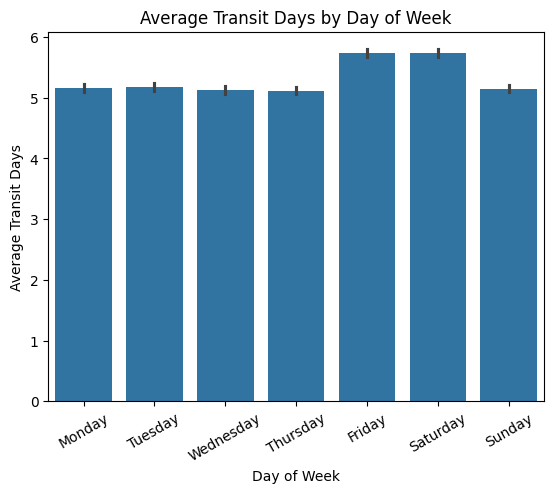

In [ ]:
# Barplot of Average Transit Days by Week
sns.barplot(data=train, x='ship_dow', y='transit_days', estimator='mean')
plt.title('Average Transit Days by Day of Week')
plt.xlabel("Day of Week")
plt.ylabel("Average Transit Days")

week = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
plt.xticks(
    ticks=range(7),
    labels=week
)
plt.xticks(rotation=30)

In [ ]:
from sklearn.metrics import mean_absolute_error  # average size of our mistakes, in days

#sort shipments by date
train = train.sort_values("ship_date").reset_index(drop=True)

#find the 80% cutoff
cut = int(len(train) * 0.8)

#older 80% used for training
tr = train.iloc[:cut].copy()

#newest 20% used for validation
val = train.iloc[cut:].copy()

#check the date ranges and row counts
print("tr: ", tr["ship_date"].min().date(), "to", tr["ship_date"].max().date(), len(tr))
print("val:", val["ship_date"].min().date(), "to", val["ship_date"].max().date(), len(val))

#use promised days as the prediction and measure the average error
print("Naive MAE:", mean_absolute_error(val["transit_days"], val["promised_days"]))

tr:  2024-01-01 to 2025-08-05 31959
val: 2025-08-05 to 2025-12-30 7990
Naive MAE: 0.8409261576971214


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor  # the model for predicting a number
from sklearn.metrics import mean_absolute_error, mean_squared_error  # ways to measure errors

#choose which columns the model can use
#remove the answer, columns that reveal the answer, and columns that are just labels
drop = ["transit_days", "delivered_on_time", "shipment_id",
        "order_date", "ship_date", "origin_zip", "dest_zip"]

#use everything except the dropped columns as features
features = [c for c in train.columns if c not in drop]

#create feature tables for training and validation
X_tr, X_val = tr[features].copy(), val[features].copy()

#tell the model which text columns are categories
for c in X_tr.select_dtypes(include="object").columns:
    cats = pd.CategoricalDtype(X_tr[c].unique())
    X_tr[c] = X_tr[c].astype(cats)
    X_val[c] = X_val[c].astype(cats)

#convert True/False columns to 1/0
for c in X_tr.select_dtypes(include="bool").columns:
    X_tr[c] = X_tr[c].astype(int)
    X_val[c] = X_val[c].astype(int)

#create the model
model = HistGradientBoostingRegressor(
    loss="absolute_error", categorical_features="from_dtype", random_state=42
)

# train the model using the older shipments
model.fit(X_tr, tr["transit_days"])

#predict transit days for the newer shipments
pred = model.predict(X_val)

#compare the predictions to the actual transit days
naive = mean_absolute_error(val["transit_days"], val["promised_days"])  #carrier's promise
mae = mean_absolute_error(val["transit_days"], pred)                    #model's average error
rmse = mean_squared_error(val["transit_days"], pred) ** 0.5             #gives more weight to big errors
within1 = (abs(val["transit_days"] - pred) <= 1).mean()                 #predictions within 1 day

print("Naive MAE (promised days):", round(naive, 3))
print("Model MAE:", round(mae, 3))
print("Model RMSE:", round(rmse, 3))
print("Within +/-1 day:", round(within1 * 100, 1), "%")

Naive MAE (promised days): 0.841
Model MAE: 0.546
Model RMSE: 0.775
Within +/-1 day: 86.6 %
